In [27]:
from dependencies import *
from save_data import *
from defaults import *

In [28]:
# number of runs to analyze
iters = 100_000

# read in file
iter_str = str(iters) if iters < 1000 else f"{int(iters/1000)}k"
filename = f"data/Franklin_{iter_str}.nc"

# summary stats for other thresholds
summary_stats(filename,threshold_temp=260,replace_stats=True)
summary_stats(filename,threshold_temp=270,replace_stats=True)

Stats group for 260 K already exists; deleting and remaking
Stats group for 270 K already exists; deleting and remaking


In [29]:
def plot_snowball_vs_threshold(filename, threshold_list,
                                min_time=0.9, max_time=2.15,
                                return_data=False, verbose=False):
    percentages = []

    for threshold in threshold_list:
        if verbose:
            print(f"Threshold temp = {threshold} K")
        stats = quick_summary_stats(filename,
                                    threshold_temp=threshold,
                                    min_time=min_time,
                                    max_time=max_time,
                                    verbose=False)
        percentages.append(stats["snowball_flag_percentage"])

    return percentages

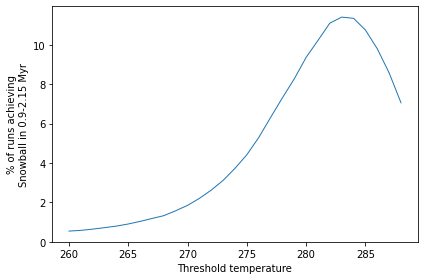

In [36]:
thresholds = np.arange(260,288+1,1)
percentages = plot_snowball_vs_threshold(filename, thresholds)

fig, ax = plt.subplots()

ax.plot(thresholds,percentages)

ax.set_xlabel("Threshold temperature")
ax.set_ylabel("% of runs achieving\nSnowball in 0.9-2.15 Myr")

plt.tight_layout()
plt.show()

In [37]:
def quick_summary_stats_delta(filename,
                               delta_temp=8,
                               min_time=0.9,
                               max_time=2.15,
                               verbose=True):
    with Dataset(filename, "r") as ncfile:
        # read in data
        T = ncfile.variables["temperature"][:]
        t = ncfile.variables["time"][:]

        # time indices
        early_index = (t >= min_time).argmax()
        late_index = (t >= max_time).argmax()

        # normalized temperature
        dT = T - T[:, [0]]  # shape-preserving broadcast

        # conditions based on normalized temperature change
        late_condition = (dT[:, :late_index] <= -delta_temp).any(axis=1)
        early_condition = (dT[:, :early_index] <= -delta_temp).any(axis=1)
        snowball_condition = late_condition & ~early_condition

        # compute percentages
        iters = len(T)
        percentages = {
            "late_flag_percentage": (late_condition.sum() / iters * 100),
            "early_flag_percentage": (early_condition.sum() / iters * 100),
            "snowball_flag_percentage": (snowball_condition.sum() / iters * 100),
        }

        if verbose:
            print(f"Analyzing for relative temperature drop ≥ {delta_temp}K")
            for name, value in percentages.items():
                print(f"{name.replace('_', ' ').capitalize()}: {value:.2f}%")

        return percentages


In [38]:
quick_summary_stats_delta(filename)

Analyzing for relative temperature drop ≥ 8K
Late flag percentage: 19.29%
Early flag percentage: 10.47%
Snowball flag percentage: 8.82%


{'late_flag_percentage': 19.291,
 'early_flag_percentage': 10.471,
 'snowball_flag_percentage': 8.82}

In [49]:
def threshold_stats(filename, dT_list,
                    min_time=0.9, max_time=2.15,
                    return_data=False, verbose=False):
    percentages = []

    for dT in dT_list:
        if verbose:
            print(f"Threshold delta = {dT} K")
        stats = quick_summary_stats_delta(filename,
                                    delta_temp=dT,
                                    min_time=min_time,
                                    max_time=max_time,
                                    verbose=False)
        percentages.append(stats)

    return percentages

In [55]:
deltas = np.arange(1,30,1)
stats = threshold_stats(filename, deltas, verbose=True)

early_percentages = [i['early_flag_percentage'] for i in stats]
snowball_percentages = [i['snowball_flag_percentage'] for i in stats]

Threshold delta = 1 K
Threshold delta = 2 K
Threshold delta = 3 K
Threshold delta = 4 K
Threshold delta = 5 K
Threshold delta = 6 K
Threshold delta = 7 K
Threshold delta = 8 K
Threshold delta = 9 K
Threshold delta = 10 K
Threshold delta = 11 K
Threshold delta = 12 K
Threshold delta = 13 K
Threshold delta = 14 K
Threshold delta = 15 K
Threshold delta = 16 K
Threshold delta = 17 K
Threshold delta = 18 K
Threshold delta = 19 K
Threshold delta = 20 K
Threshold delta = 21 K
Threshold delta = 22 K
Threshold delta = 23 K
Threshold delta = 24 K
Threshold delta = 25 K
Threshold delta = 26 K
Threshold delta = 27 K
Threshold delta = 28 K
Threshold delta = 29 K


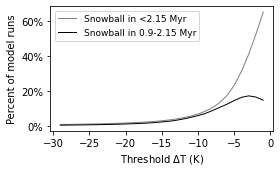

In [65]:
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({'legend.fontsize':9,
                     'font.size':10,
                     'lines.linewidth':1,
                     'axes.titlesize':10})

fig, ax = plt.subplots(figsize=(4,2.5))

ax.plot(-1*deltas,early_percentages,c='grey',
        label='Snowball in <2.15 Myr')
ax.plot(-1*deltas,snowball_percentages,c='k',
        label='Snowball in 0.9-2.15 Myr')

ax.set_xlabel("Threshold $\Delta$T (K)")
ax.set_ylabel("Percent of model runs")

ax.legend()

ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.savefig('figs/thresholds.jpg',format='jpg',bbox_inches='tight',dpi=600)
plt.show()

In [68]:
## copied over from 3.1_Franklin_analyze and modified

def plot_temp_density(filename,figname=None,
                      normed=False,threshold_temp=280,
                      hist=False,kdeplot=True,fill=False,
                      extra_labels=False):
    
    # for getting stats for right threshold temp
    group_name = f"stats{int(threshold_temp)}" if threshold_temp != 280 else "stats"
    
    # fetch data
    with Dataset(filename, "r") as ds:
        if not normed:
            min_T = ds.groups[group_name].variables['min_temp'][:]
        else:
            min_T = ds.groups[group_name].variables['min_normed_temp'][:]
    
    # filter out nans
    min_T = min_T[~np.isnan(min_T)]
    
    fig,ax = plt.subplots(figsize=(4,2.5))
    if hist:
        ax.hist(min_T,bins=100,density=True,color='k',alpha=0.3,histtype='step',
               label='binned data' if hist and kdeplot and extra_labels else None)
    if kdeplot:
        kde = sns.kdeplot(min_T, color='k',
                          bw_adjust=0.2 if normed else 1,
                          clip=(min_T.min(), min_T.max()),
                          label='KDE-smoothed' if hist and kdeplot and extra_labels else None)
        if fill:
            x_values = np.array(kde.get_lines()[0].get_xdata())
            y_values = np.array(kde.get_lines()[0].get_ydata())
            ax.fill_between(x_values, y_values, where=(x_values <= threshold_temp),
                            color='cadetblue', alpha=0.3)
        
    ax.set_xlim(245,305) if not normed else ax.set_xlim(-40,5)
    if threshold_temp and threshold_temp>ax.get_xlim()[0] and threshold_temp<ax.get_xlim()[1]:
        ax.axvline(threshold_temp, color='cadetblue', label='Snowball threshold_temp')
        
    ax.set_xlabel('Minimum temperature (K) within 2.15 Myr') if not normed else ax.set_xlabel('Min. temperature anomaly ($\Delta$K) within 2.15 Myr')
    ax.set_ylabel('Probability Density')
    ax.set_yticks([])
    ax.legend(loc='upper left',frameon=False)
    
    plt.tight_layout()
    if figname:
        plt.savefig(figname+'.jpg',format='jpg',bbox_inches='tight',dpi=600)
    plt.show()
    
def make_label(var_object):
    long_name = var_object.long_name
    units = var_object.units.replace("^2", "$^2$")
    label = f"{long_name} ({units})" if units else long_name
    return label

def param_density_plot(filename, param_name, threshold_temp=280,
                       ax=None, labels_on=False, label_wrap=True,
                      verbose=False):    
    with Dataset(filename, 'r') as ds:
         # for getting stats for right threshold temp
        group_name = f"stats{int(threshold_temp)}" if threshold_temp != 280 else "stats"
    
        param_data = ds.groups['params'].variables[param_name][:]
        late_flag = ds.groups[group_name].variables['late_flag'][:]
        snowball_flag = ds.groups[group_name].variables['snowball_flag'][:]
        
        try:
            x_label = make_label(ds.groups['params'].variables[param_name])
        except:
            print(f"Couldn't find metadata for {param_name}")
            x_label = param_name
            
    if verbose:
        mean_all = np.mean(param_data)
        mean_late = np.mean(param_data[late_flag == 1])
        mean_snowball = np.mean(param_data[snowball_flag == 1])
        print(f"    Mean of {param_name} (whole space): {mean_all:.4f}")
        print(f"    Mean of {param_name} (snowball any time): {mean_late:.4f}")
        print(f"    Mean of {param_name} (snowball right time): {mean_snowball:.4f}")
    
    
    ax_given = ax
    if not ax:
        fig,ax = plt.subplots(figsize=(4,2.5))
        labels_on = True
        
    labels = ['Distribution\nsampled','Snowball in\n<2.15 Myr','Snowball in\n0.9-2.15 Myr']
    if not label_wrap:
        labels = [label.replace('\n',' ') for label in labels]
    if not labels_on:
        labels = [None,None,None]
        
    sns.kdeplot(param_data, ax=ax, color='#4D4D4D',label=labels[0])
    sns.kdeplot(param_data[late_flag == 1], ax=ax, color='#8566CC',label=labels[1])
    sns.kdeplot(param_data[snowball_flag == 1], ax=ax, color='#47B3A1',label=labels[2])

    #ax.set_yticks([])
    ax.set_xlabel(x_label)
    ax.set_ylabel('Probability Density')
    if not ax_given:
        ax.legend(loc='upper center', bbox_to_anchor=(0.5,1.2), ncol=3)
    return ax

Plotting N0
    Mean of N0 (whole space): 8.2312
    Mean of N0 (snowball any time): 7.7726
    Mean of N0 (snowball right time): 9.1555
Plotting T0
    Mean of T0 (whole space): 287.7082
    Mean of T0 (snowball any time): 286.6182
    Mean of T0 (snowball right time): 286.1812
Plotting b
    Mean of b (whole space): 5.4895
    Mean of b (snowball any time): 5.5068
    Mean of b (snowball right time): 5.5046
Plotting V
    Mean of V (whole space): 8.7896
    Mean of V (snowball any time): 8.5365
    Mean of V (snowball right time): 8.5366
Plotting degass
    Mean of degass (whole space): 5.0033
    Mean of degass (snowball any time): 4.5315
    Mean of degass (snowball right time): 5.2249
Plotting A0
    Mean of A0 (whole space): 6.8050
    Mean of A0 (snowball any time): 8.2957
    Mean of A0 (snowball right time): 7.3659
Plotting B0
    Mean of B0 (whole space): 2.0553
    Mean of B0 (snowball any time): 2.3707
    Mean of B0 (snowball right time): 2.4024
Plotting emp_dur
    Mean o

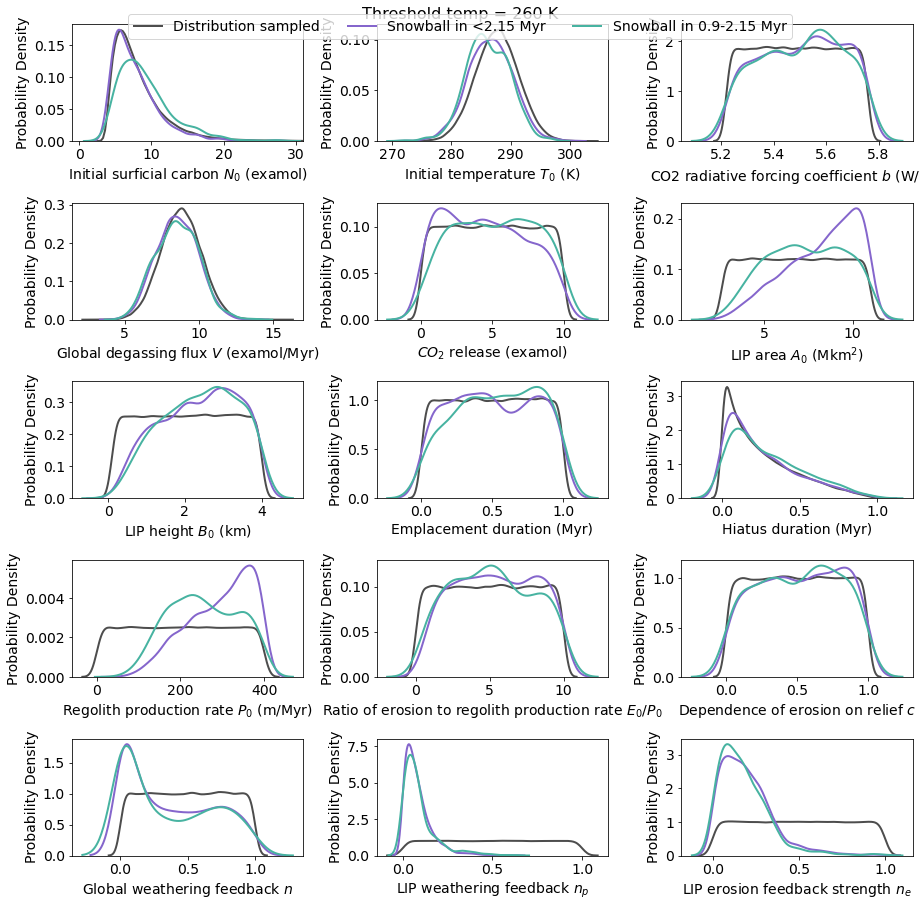

In [78]:
plt.rcParams.update({'legend.fontsize':12,
                     'font.size':14,
                     'lines.linewidth':2})

# in order to plot
param_list = ['N0','T0','b', # background climate
              'V','degass','A0', # emplacement 1
              'B0','emp_dur','erup_freq', # emplacement 2
              'P0','E_P','c', # weathering & erosion
              'n','n_p','n_e'] # feedback strengths

fig,axs = plt.subplots(5,3,figsize=(13,13))

for i in range(len(param_list)):
    ax = axs.reshape(-1)[i]
    param_name = param_list[i]
    print("Plotting",param_name)
    if param_name == 'N0':
        ax.set_xlim(-1,31)
    if i == 0:
        param_density_plot(filename=filename,threshold_temp=260,
                           param_name=param_name,ax=ax,verbose=True,
                           labels_on=True,label_wrap=False)
    else:
        param_density_plot(filename=filename,threshold_temp=260,
                           param_name=param_name,ax=ax,verbose=True)
    
fig.suptitle('Threshold temp = 260 K', fontsize=16, y=0.97)
fig.legend(loc='upper center', bbox_to_anchor=(0.5,0.97), ncol=3, fontsize=14)
fig.subplots_adjust(top=0.92, hspace=0.3)
plt.tight_layout()
plt.show()